In [1]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
EXPORT_PATH = ''
DPI = 300
IMG_TYPE = '.tif'
# E_NAME = ['MAE', 'RMSE']  # MAE, MAPE, R^2
E_NAME = ['R^2', 'MAE']  # MAE, MAPE, R^2

In [3]:
folder_name = [
    '20260120_163808',
    '20260120_185839',
]
abs_folder = [os.path.join(r'E:\DataForCode\2_STGNNOutput', f_name, 'Result') for f_name in folder_name]

legend_l = [
    '[48_12_20]',
    '[48_12_10]',
]

In [4]:
plt_df = pd.DataFrame()

for i, name in enumerate(abs_folder):
    # try:
    #     file_path = EXPORT_PATH + f'{name}.pickle'
    #     _ = pd.read_pickle(file_path)
    # except FileNotFoundError or EOFError as e:
    file_path = EXPORT_PATH + f'{name}.pkl'
    _ = pd.read_pickle(file_path)

    print(file_path)

    cur_df = _[_['Type'].isin(E_NAME)].copy()
    # cur_df['Run_Id'] = legend_l[i]
    cur_df['Model'] = legend_l[i]
    plt_df = pd.concat([plt_df, cur_df])

plt_df = (
    plt_df
    # .drop('Type', axis=1)
    .reset_index(drop=True)
)
plt_df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'E:\\DataForCode\\2_STGNNOutput\\20260120_163808\\Result.pkl'

In [ ]:
plt_df_long = plt_df.melt(id_vars=['Run_Id', 'Model', 'Type'], var_name='Horizon Step', value_name='Value')
plt_df_long.head()

In [ ]:
plt_df_long

NameError: name 'plt_df_long' is not defined

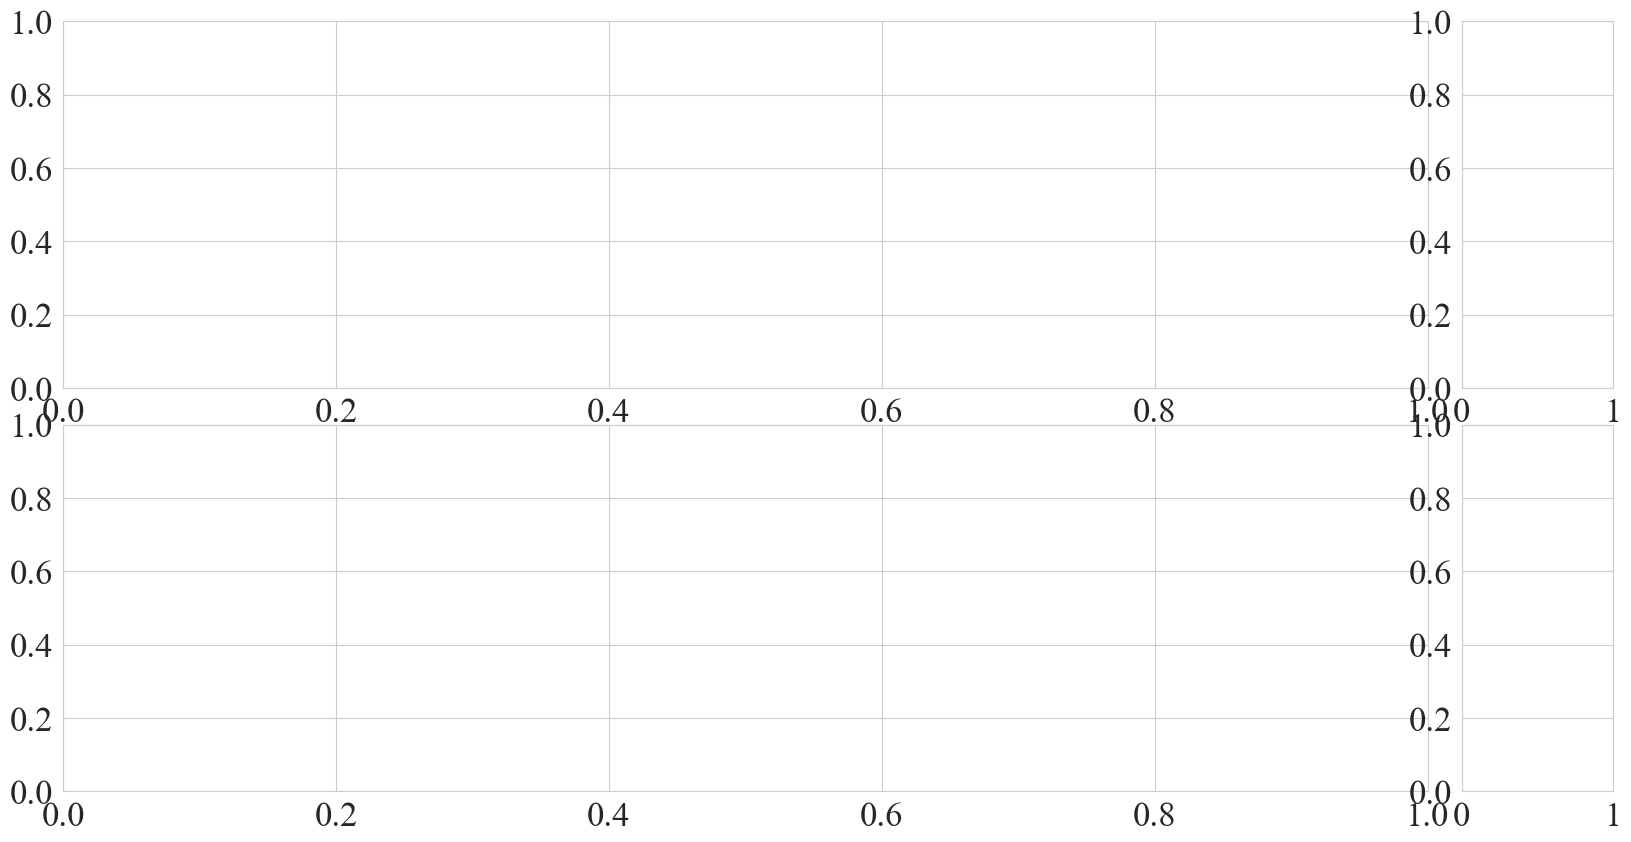

In [5]:
from matplotlib.gridspec import GridSpec

plt.rcParams.update({
    'font.size': 25,
    'font.family': ['Times New Roman', 'SimSun'],
    'mathtext.fontset': 'custom',  # 自定义数学字体
    'mathtext.rm': 'Times New Roman',  # 数学公式中正常字体 (Roman)
    'mathtext.it': 'Times New Roman:italic',  # 数学公式中斜体
    'mathtext.bf': 'Times New Roman:bold',  # 数学公式中粗体
})

# 子图布局
COL_NUM, ROW_NUM = 2, len(E_NAME)
fig = plt.figure(figsize=(20, 5 * len(E_NAME)))
# 创建 GridSpec 对象，控制列宽
gs = GridSpec(ROW_NUM, COL_NUM, width_ratios=[0.9, 0.1])  # 第一列宽度占 80%，第二列占 20%

# 创建子图
ax_arr = []
for i in range(ROW_NUM):
    # 第一列子图
    ax1 = fig.add_subplot(gs[i, 0])
    # 第二列子图，共享第一列的 y 轴
    ax2 = fig.add_subplot(gs[i, 1])  # sharey=ax1 表示第二列与第一列共享 y 轴
    ax_arr.append([ax1, ax2])

fig.subplots_adjust(hspace=0.1, wspace=0.045)

palette = {
    'None': '#f20c00',  # 蓝色
    'Week': '#ffa631',  # 橙色
    'Hour': '#0eb83a',  # 绿色
    'Hour(sin-cos)': '#177cb0',  # 红色
    'Hour(sin-cos, Att)': '#815476'  # 红色
}

for i, name in enumerate(E_NAME):
    cur_plt = sns.boxplot(
        data=plt_df_long[plt_df_long['Type'] == name],
        x='Horizon Step',
        y='Value',
        hue='Model',
        # palette=palette,  # 加上这里！
        width=1,
        ax=ax_arr[i][0]
    )

    y_label = f'${name}$' if '^' in name else name
    cur_plt.set_ylabel(y_label)

    # 删除子图的图例
    cur_plt.get_legend().remove()

    # 获取x轴刻度位置
    xticks = cur_plt.get_xticks()

    # 在x轴的每个刻度之间添加竖直线
    for tick in xticks[:-1]:  # 不包括最后一个
        cur_plt.axvline(x=tick + 0.5, color='#ccc', linestyle='--', linewidth=0.5)

for i, name in enumerate(E_NAME):
    cur_plt = sns.boxplot(
        data=plt_df_long[plt_df_long['Type'] == name].drop('Horizon Step', axis=1),
        x='Model',
        y='Value',
        hue='Model',
        width=.8,
        palette=palette,  # 加上这里！
        ax=ax_arr[i][1]
    )

    cur_plt.set_ylabel(None)

    # 删除子图的图例
    # cur_plt.get_legend().remove()

    # 获取x轴刻度位置
    xticks = cur_plt.get_xticks()

    cur_plt.set_yticklabels([])  # 删除 y 轴刻度标签

    # 在x轴的每个刻度之间添加竖直线
    for tick in xticks[:-1]:  # 不包括最后一个
        cur_plt.axvline(x=tick + 0.5, color='#ccc', linestyle='--', linewidth=0.5)

for i in range(ROW_NUM):
    for j in range(COL_NUM):
        ax_arr[i][j].grid(False)
        if not (i == 1 and j == 0):
            ax_arr[i][j].set_xticklabels([])
            ax_arr[i][j].set_xlabel(None)

ax_arr[1][0].set_ylabel('MAE (m)')

# 三个子图的图例相同，获取最后一个子图的图例
lines, labels = fig.axes[-2].get_legend_handles_labels()
fig.legend(lines, labels, ncol=5, loc='lower center',
           bbox_to_anchor=(0.5, -.1))

# ax_arr[0][0].set_ylim([.875, .965])
# ax_arr[0][1].set_ylim([.875, .965])
# ax_arr[1][0].set_ylim([0.02, 0.04])
# ax_arr[1][1].set_ylim([0.02, 0.04])

# 保存图片
# from datetime import datetime
# 
# cur_time_str = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')  # 获取当前日期和时间
# fig.savefig(f'./export/ModelComparison_[DifferentMatrix]_[{cur_time_str}].svg', dpi=100, bbox_inches='tight')